In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from matplotlib import pyplot as plt


In [ ]:
file_path = 'titanic.csv'

df = pd.read_csv(file_path, sep=';')
print(df.head())

red_df = df.drop(['Life Boat', 'Name', 'Ticket Number', 'Cabin'], axis=1)


  Passenger Class                                             Name     Sex  \
0           First                    Allen, Miss. Elisabeth Walton  Female   
1           First                   Allison, Master. Hudson Trevor    Male   
2           First                     Allison, Miss. Helen Loraine  Female   
3           First             Allison, Mr. Hudson Joshua Creighton    Male   
4           First  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  Female   

       Age  No of Siblings or Spouses on Board  \
0  29.0000                                   0   
1   0.9167                                   1   
2   2.0000                                   1   
3  30.0000                                   1   
4  25.0000                                   1   

   No of Parents or Children on Board Ticket Number  Passenger Fare    Cabin  \
0                                   0         24160        211.3375       B5   
1                                   2        113781        151.5500  C

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'No of Siblings or Spouses on Board'}>],
       [<Axes: title={'center': 'No of Parents or Children on Board'}>,
        <Axes: title={'center': 'Passenger Fare'}>]], dtype=object)

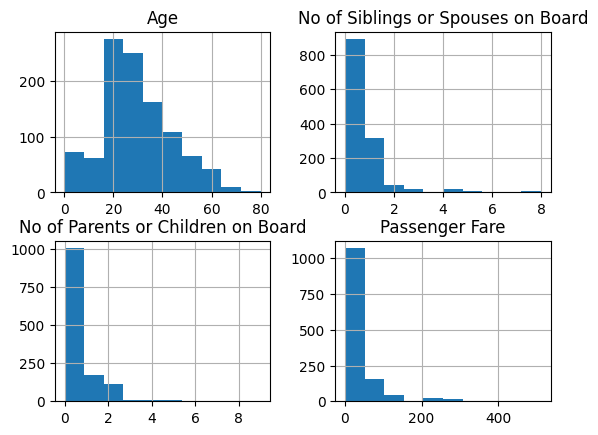

In [ ]:
df.hist()

  Passenger Class     Sex      Age  No of Siblings or Spouses on Board  \
0           First  Female  29.0000                                   0   
1           First    Male   0.9167                                   1   
2           First  Female   2.0000                                   1   
3           First    Male  30.0000                                   1   
4           First  Female  25.0000                                   1   

   No of Parents or Children on Board  Passenger Fare Port of Embarkation  \
0                                   0        211.3375         Southampton   
1                                   2        151.5500         Southampton   
2                                   2        151.5500         Southampton   
3                                   2        151.5500         Southampton   
4                                   2        151.5500         Southampton   

  Survived  
0      Yes  
1      Yes  
2       No  
3       No  
4       No  


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'No of Siblings or Spouses on Board'}>],
       [<Axes: title={'center': 'No of Parents or Children on Board'}>,
        <Axes: title={'center': 'Passenger Fare'}>]], dtype=object)

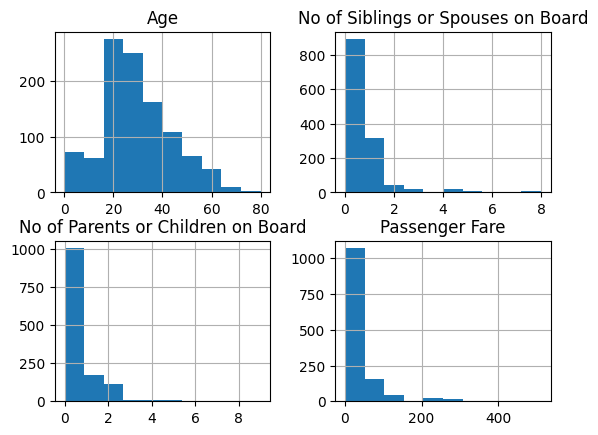

In [ ]:
print(red_df.head())
red_df.hist()

In [ ]:
enc = OneHotEncoder()
encoded = enc.fit_transform(red_df[["Passenger Class","Sex","Port of Embarkation"]]).toarray()
enc.categories_

[array(['First', 'Second', 'Third'], dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['Cherbourg', 'Queenstown', 'Southampton', nan], dtype=object)]

       Age  No of Siblings or Spouses on Board  \
0  29.0000                                   0   
1   0.9167                                   1   
2   2.0000                                   1   
3  30.0000                                   1   
4  25.0000                                   1   

   No of Parents or Children on Board  Passenger Fare Survived  \
0                                   0        211.3375      Yes   
1                                   2        151.5500      Yes   
2                                   2        151.5500       No   
3                                   2        151.5500       No   
4                                   2        151.5500       No   

   Passenger Class_First  Passenger Class_Second  Passenger Class_Third  \
0                    1.0                     0.0                    0.0   
1                    1.0                     0.0                    0.0   
2                    1.0                     0.0                    0.0   
3 

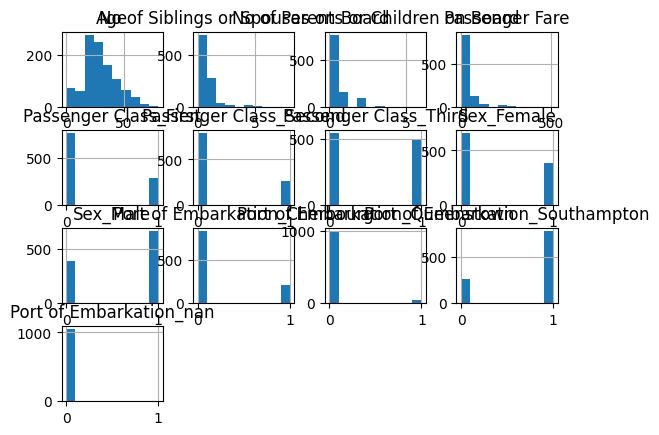

In [ ]:
f_n = enc.get_feature_names_out(["Passenger Class", "Sex", "Port of Embarkation"])
enc_df = pd.DataFrame(encoded, columns=f_n)
fin_df = pd.concat([red_df.drop(columns=["Passenger Class", "Sex", "Port of Embarkation"]), enc_df], axis=1)


fin_df = fin_df.dropna()
fin_df.hist()
print(fin_df.head())

In [ ]:
X = fin_df.drop(["Survived"],axis=1)
y = fin_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify = y)
#X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

In [ ]:
dtc1 = DecisionTreeClassifier(random_state=30)
dtc1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=30)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = dtc1.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7834394904458599

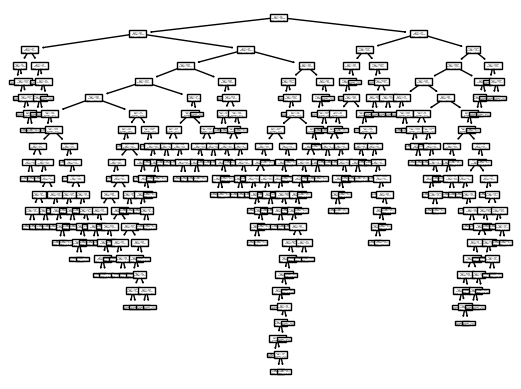

In [ ]:
plot_tree(dtc1, proportion=True)
plt.show()

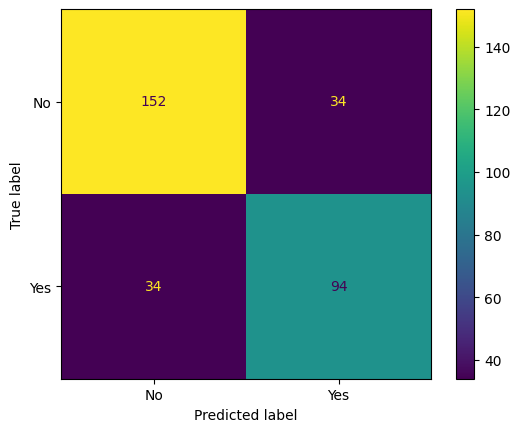

              precision    recall  f1-score   support

          No       0.82      0.82      0.82       186
         Yes       0.73      0.73      0.73       128

    accuracy                           0.78       314
   macro avg       0.78      0.78      0.78       314
weighted avg       0.78      0.78      0.78       314

Czułość (Sensitivity / Recall dla 'Przeżył'): 0.7344
Swoistość (Specificity / Recall dla 'Nie przeżył'): 0.8172


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dtc1.classes_)
disp.plot()
plt.show()

report = classification_report(y_test, y_pred)
print(report)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Czułość (Sensitivity / Recall dla 'Przeżył'): {sensitivity:.4f}")
print(f"Swoistość (Specificity / Recall dla 'Nie przeżył'): {specificity:.4f}")

In [ ]:
dtc2 = DecisionTreeClassifier(random_state=30, ccp_alpha=0.005)
dtc2.fit(X_train, y_train)
y_pred = dtc2.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8343949044585988

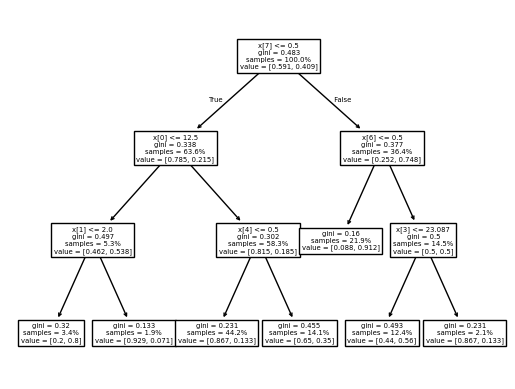

In [ ]:
plot_tree(dtc2, proportion=True)
plt.show()

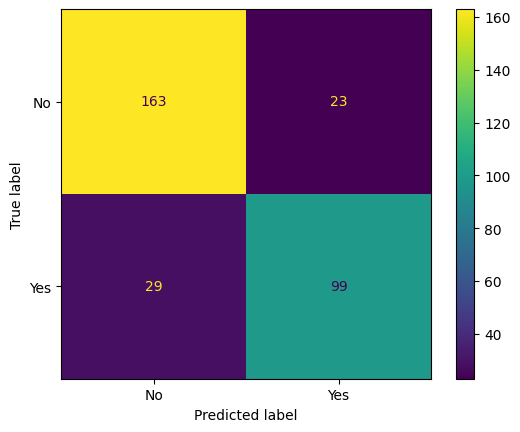

              precision    recall  f1-score   support

          No       0.85      0.88      0.86       186
         Yes       0.81      0.77      0.79       128

    accuracy                           0.83       314
   macro avg       0.83      0.82      0.83       314
weighted avg       0.83      0.83      0.83       314

Czułość (Sensitivity / Recall dla 'Przeżył'): 0.7734
Swoistość (Specificity / Recall dla 'Nie przeżył'): 0.8763


In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dtc2.classes_)
disp.plot()
plt.show()

report = classification_report(y_test, y_pred)
print(report)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Czułość (Sensitivity / Recall dla 'Przeżył'): {sensitivity:.4f}")
print(f"Swoistość (Specificity / Recall dla 'Nie przeżył'): {specificity:.4f}")

In [ ]:
dtc3 = DecisionTreeClassifier(random_state=0, max_leaf_nodes=3)
dtc3.fit(X_train, y_train)
y_pred = dtc3.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.821656050955414

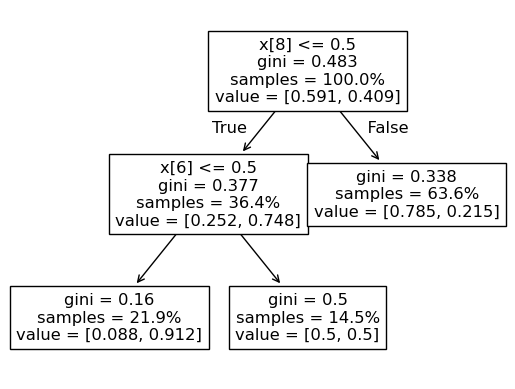

In [ ]:
plot_tree(dtc3, proportion=True)
plt.show()

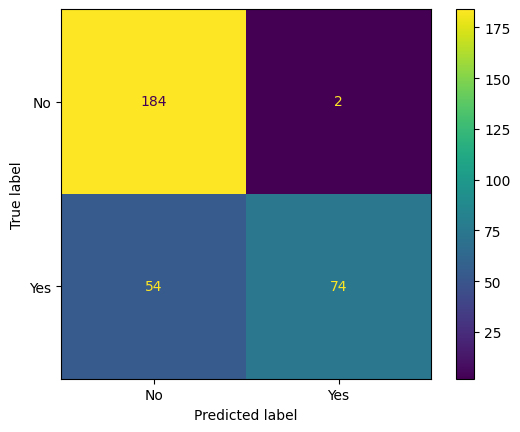

              precision    recall  f1-score   support

          No       0.77      0.99      0.87       186
         Yes       0.97      0.58      0.73       128

    accuracy                           0.82       314
   macro avg       0.87      0.78      0.80       314
weighted avg       0.85      0.82      0.81       314

Czułość (Sensitivity / Recall dla 'Przeżył'): 0.5781
Swoistość (Specificity / Recall dla 'Nie przeżył'): 0.9892


In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dtc3.classes_)
disp.plot()
plt.show()

report = classification_report(y_test, y_pred)
print(report)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Czułość (Sensitivity / Recall dla 'Przeżył'): {sensitivity:.4f}")
print(f"Swoistość (Specificity / Recall dla 'Nie przeżył'): {specificity:.4f}")

Dziesięciokrotna walidacja krzyżowa stratyfikowana

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=30)

clf1 = DecisionTreeClassifier(random_state=42, ccp_alpha=0)
scores_1 = cross_val_score(clf1, X, y, cv=cv, scoring='accuracy')
mean_acc = np.mean(scores_1)
std_acc = np.std(scores_1)
print(mean_acc)
print(std_acc)

0.764569597069597
0.035874872599818225


In [ ]:
clf_005 = DecisionTreeClassifier(random_state=30, ccp_alpha=0.005)
scores_005 = cross_val_score(clf_005, X, y, cv=cv, scoring='accuracy')
mean_acc = np.mean(scores_005)
std_acc = np.std(scores_005)
print(mean_acc)
print(std_acc)

0.8085531135531134
0.037382948942809406


In [ ]:
clf_05 = DecisionTreeClassifier(random_state=30, ccp_alpha=0.05)
scores_05 = cross_val_score(clf_05, X, y, cv=cv, scoring='accuracy')
mean_acc = np.mean(scores_05)
std_acc = np.std(scores_05)
print(mean_acc)
print(std_acc)

0.7788644688644689
0.03185080683542104


Testowanie modeli RandomForrest ccp = 0

In [ ]:
rfc1 = RandomForestClassifier(random_state=30,n_estimators=10)
rfc1.fit(X_train,y_train)
scores = cross_val_score(rfc1, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7712545787545788
0.03074672259119599


In [ ]:
rfc2 = RandomForestClassifier(random_state=30,n_estimators=100)
rfc2.fit(X_train,y_train)
scores = cross_val_score(rfc2, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7693040293040293
0.03980670955389544


In [ ]:
rfc3 = RandomForestClassifier(random_state=30,n_estimators=40)
rfc3.fit(X_train,y_train)
scores = cross_val_score(rfc3, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7731227106227105
0.03504327015732473


Testowanie modeli RandomForrest ccp = 0.005

In [ ]:
rfc4 = RandomForestClassifier(random_state=30,n_estimators=10, ccp_alpha=0.005)
rfc4.fit(X_train,y_train)
scores = cross_val_score(rfc4, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7941849816849816
0.03203969570800153


In [ ]:
rfc5 = RandomForestClassifier(random_state=30,n_estimators=40, ccp_alpha=0.005)
rfc5.fit(X_train,y_train)
scores = cross_val_score(rfc5, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7903846153846155
0.030424382299077197


In [ ]:
rfc6 = RandomForestClassifier(random_state=30,n_estimators=100, ccp_alpha=0.005)
rfc6.fit(X_train,y_train)
scores = cross_val_score(rfc6, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7913369963369963
0.03171501255283746


Test modeli RandomForrest cpp = 0.05

In [ ]:
rfc7 = RandomForestClassifier(random_state=30,n_estimators=10, ccp_alpha=0.05)
rfc7.fit(X_train,y_train)
scores = cross_val_score(rfc7, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7788644688644689
0.03185080683542104


In [ ]:
rfc8 = RandomForestClassifier(random_state=30,n_estimators=40, ccp_alpha=0.005)
rfc8.fit(X_train,y_train)
scores = cross_val_score(rfc8, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7903846153846155
0.030424382299077197


In [ ]:
rfc9 = RandomForestClassifier(random_state=30,n_estimators=100, ccp_alpha=0.005)
rfc9.fit(X_train,y_train)
scores = cross_val_score(rfc9, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7913369963369963
0.03171501255283746


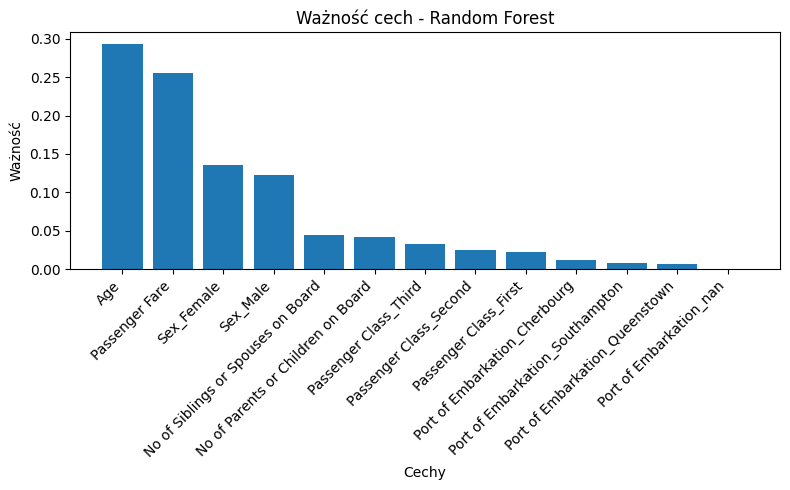

In [ ]:
importances = rfc1.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Cech {i}" for i in range(X_train.shape[1])]

plt.figure(figsize=(8, 5))
plt.title("Ważność cech - Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), np.array(feature_names)[indices], rotation=45, ha="right")
plt.xlabel("Cechy")
plt.ylabel("Ważność")
plt.tight_layout()
plt.show()

Testowanie modelu Gradient Boosting: max_depth = 1

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbc1 = GradientBoostingClassifier(random_state=0, max_depth=1, n_estimators = 10)
gbc1.fit(X_train,y_train)
scores = cross_val_score(gbc1, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7788644688644689
0.03185080683542104


In [ ]:
gbc2 = GradientBoostingClassifier(random_state=0, max_depth=1, n_estimators = 40)
gbc2.fit(X_train,y_train)
scores = cross_val_score(gbc2, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7798168498168498
0.03342629331267195


In [ ]:
gbc3 = GradientBoostingClassifier(random_state=0, max_depth=1, n_estimators = 100)
gbc3.fit(X_train,y_train)
scores = cross_val_score(gbc3, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7836721611721612
0.031838067636386864


max_depth = 3

In [ ]:
gbc4 = GradientBoostingClassifier(random_state=0, max_depth=3, n_estimators = 10)
gbc4.fit(X_train,y_train)
scores = cross_val_score(gbc4, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.798992673992674
0.03152652580108794


In [ ]:
gbc5 = GradientBoostingClassifier(random_state=0, max_depth=3, n_estimators = 40)
gbc5.fit(X_train,y_train)
scores = cross_val_score(gbc5, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.8123992673992675
0.02873836480878169


In [ ]:
gbc6 = GradientBoostingClassifier(random_state=0, max_depth=3, n_estimators = 100)
gbc6.fit(X_train,y_train)
scores = cross_val_score(gbc6, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.808543956043956
0.029839966660043564


max_depth =10

In [ ]:
gbc7 = GradientBoostingClassifier(random_state=0, max_depth=10, n_estimators = 10)
gbc7.fit(X_train,y_train)
scores = cross_val_score(gbc7, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7732234432234433
0.025862505002861042


In [ ]:
gbc8 = GradientBoostingClassifier(random_state=0, max_depth=10, n_estimators = 40)
gbc8.fit(X_train,y_train)
scores = cross_val_score(gbc8, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7741300366300365
0.02525063385720572


In [ ]:
gbc9 = GradientBoostingClassifier(random_state=0, max_depth=10, n_estimators = 100)
gbc9.fit(X_train,y_train)
scores = cross_val_score(gbc9, X, y, cv=cv)
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)
print(mean_accuracy)
print(std_accuracy)

0.7683333333333333
0.029006005140409748
